# Width-Scaling SGD Experiments

Train parity networks at widths `N = 256, 512, 1024, 2048` with SGD, save train/test curves, and analyze the final checkpoints with PCA rank reduction and weight-variance scaling.


## Setup

Mount Google Drive, clone the public repo, install it in editable mode, and define the run/plot directories.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [12]:
from pathlib import Path

GITHUB_REPO_URL = "https://github.com/labofdoubt/feature-learning-parity-task.git"
REPO_DIR = Path("/content/feature-learning-parity-task")

DRIVE_ROOT = Path("/content/drive/MyDrive/ml_projects_new/parity_width_scaling_sgd_unfrozen_emb_mup")

RUNS_DIR = DRIVE_ROOT / "runs"
PLOTS_DIR = DRIVE_ROOT / "plots"
ANALYSIS_DIR = DRIVE_ROOT / "analysis"

RUNS_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
!rm -rf "$REPO_DIR"
!git clone "$GITHUB_REPO_URL" "$REPO_DIR"
%cd "$REPO_DIR"
!pip install -e .

Cloning into '/content/feature-learning-parity-task'...
remote: Enumerating objects: 103, done.
remote: Counting objects: 100% (103/103), done.
remote: Compressing objects: 100% (65/65), done.
remote: Total 103 (delta 57), reused 84 (delta 38), pack-reused 0 (from 0)
Receiving objects: 100% (103/103), 627.06 KiB | 39.19 MiB/s, done.
Resolving deltas: 100% (57/57), done.
/content/feature-learning-parity-task
Obtaining file:///content/feature-learning-parity-task
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for parity-net (pyproject.toml) ... done
  Created wheel for parity-net: filename=parity_net-0.1.0-0.editable-py3-none-any.whl size=3070 sha256=be3fbe2ac68c69549abbf5a0bcb80356ed228aa5aa63d00cdb2bb73c0df72a8e
  Stored in directory: /tmp/pip-ephem-wheel-cache-78re3ztf/wheels/a2/05/6b/5da726f55833c1e289bd27

## Train Width Sweep

This cell writes one config per width and runs training inside the notebook kernel so the progress bar renders in Colab. Existing final checkpoints are skipped unless `FORCE_RETRAIN = True`.


In [ ]:
from pathlib import Path

import yaml

from parity_net.config import load_config
from parity_net.train import train

WIDTHS = [256, 512, 1024, 2048, 4096]
FORCE_RETRAIN = False


def make_config(N: int, output_dir: Path) -> dict:
    return {
        "model": {
            "input_dim": 32,
            "relevant_dim": 16,
            "N": N,
            "L": 2,
            "activation": "relu",
            "use_readout_barrier": False,
            "embedding_weight_variance": 1.0 / 32,
            "freeze_embedding": False,
            "hidden_weight_variance": 1.0 / N,
            "readout_weight_variance": 1.0 / N,
            "use_post_activation_linear": False,
            "bias": False,
        },
        "training": {
            "num_steps": 100_000,
            "test_samples": 100_000,
            "batch_size": 512,
            "seed": 0,
            "device": "cuda",
            "dtype": "float32",
            "log_every": 1_000,
            "checkpoint_every": 1_000,
            "output_dir": str(output_dir),
            "barrier_c": None,
            "barrier_lambda": 10.0,
            "optimizer": {
                "name": "sgd",
                "lr": 1e-2,
                "lr_embedding": None,
                "lr_hidden": None,
                "lr_readout": None,
                "weight_decay": 0.0,
                "momentum": 0.9,
                "betas": [0.9, 0.999],
            },
        },
    }


def make_config_mup(N: int, output_dir: Path) -> dict:
    config = make_config(N, output_dir)
    base_lr = config["training"]["optimizer"]["lr"]
    config["model"]["readout_weight_variance"] = 256 / N**2
    config["training"]["optimizer"]["lr_embedding"] = base_lr * N / 256
    config["training"]["optimizer"]["lr_hidden"] = base_lr
    config["training"]["optimizer"]["lr_readout"] = base_lr * 256 / N
    return config


CONFIG_FACTORY = make_config_mup  # Change to make_config_mup for the muP-scaled sweep.


In [ ]:
config_paths = {}
for N in WIDTHS:
    run_dir = RUNS_DIR / f"N_{N}"
    run_dir.mkdir(parents=True, exist_ok=True)
    config = CONFIG_FACTORY(N, run_dir)
    config_path = run_dir / "config.yaml"
    with config_path.open("w") as f:
        yaml.safe_dump(config, f, sort_keys=False)
    config_paths[N] = config_path

    final_checkpoint = run_dir / "checkpoints" / "final.pt"
    if final_checkpoint.exists() and not FORCE_RETRAIN:
        print(f"N={N}: final checkpoint exists, skipping training: {final_checkpoint}")
        continue

    print(f"N={N}: training with {config_path}")
    final_path = train(load_config(config_path))
    print(f"N={N}: saved final checkpoint to {final_path}")


## Train/Test Curves

Read `metrics.csv` from each run, save one plot per width, and save combined train/test plots across widths.


In [4]:
DRIVE_ROOT = Path("/content/drive/MyDrive/ml_projects_new/parity_width_scaling_sgd_unfrozen_emb")

RUNS_DIR = DRIVE_ROOT / "runs"
PLOTS_DIR = DRIVE_ROOT / "plots"
ANALYSIS_DIR = DRIVE_ROOT / "analysis"

WIDTHS = [256, 512, 1024, 2048, 4096]

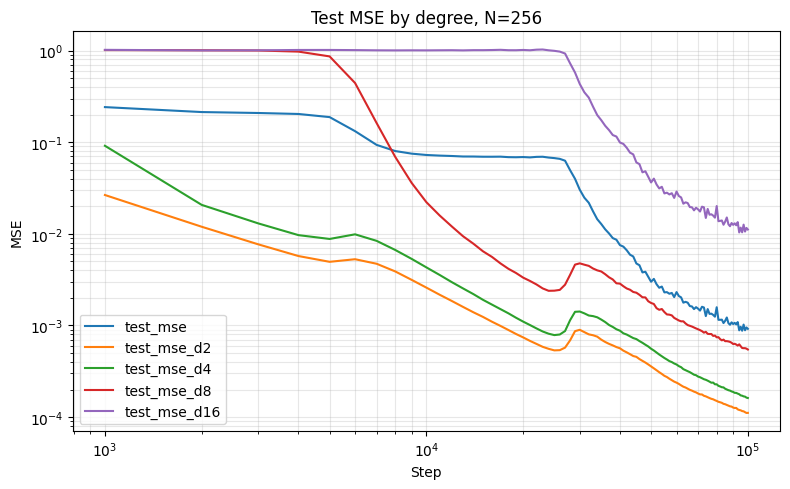

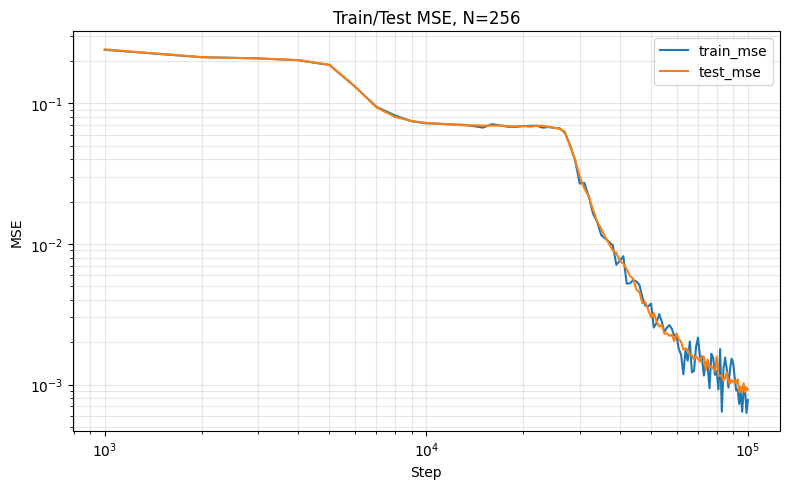

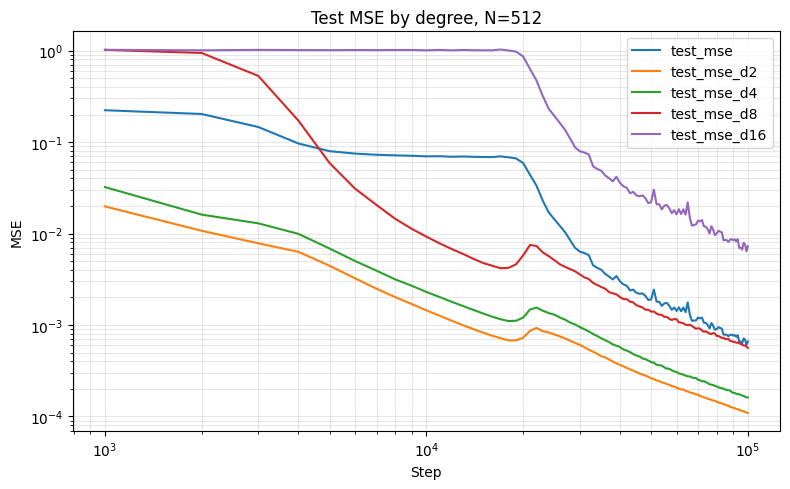

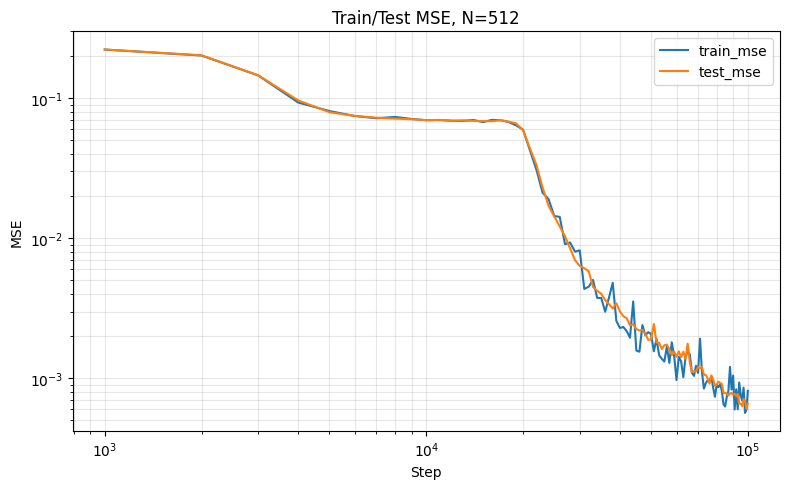

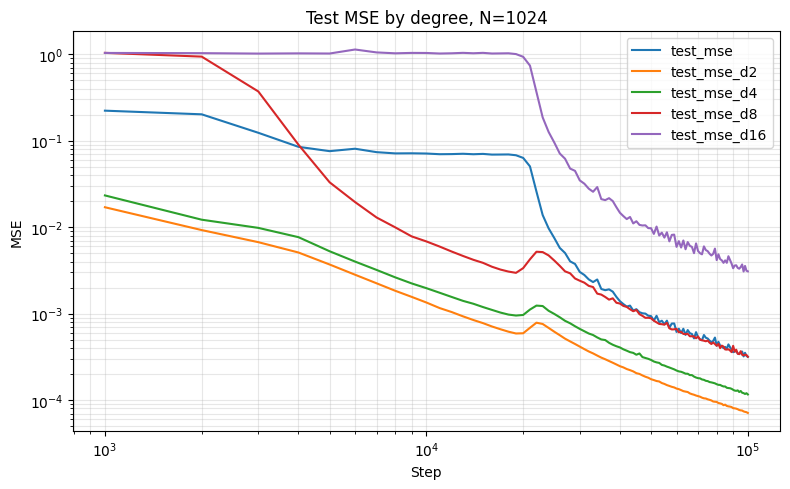

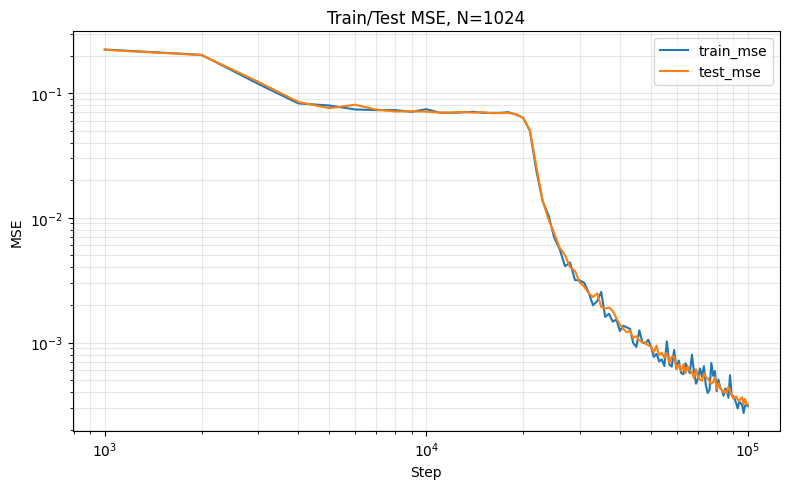

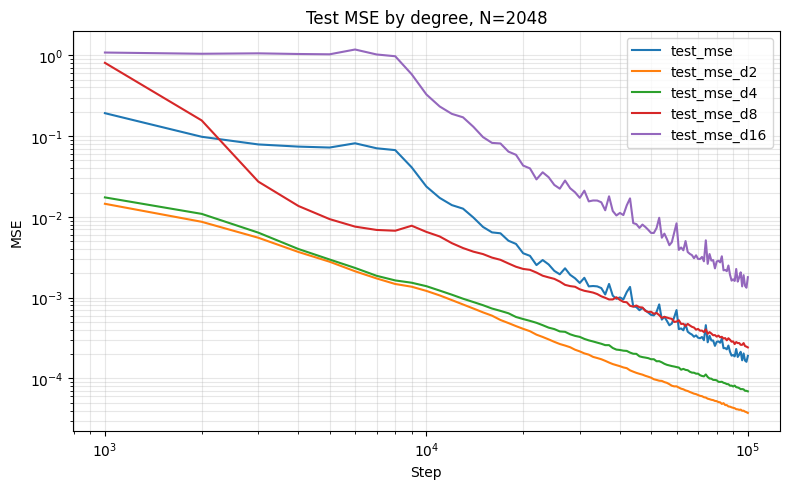

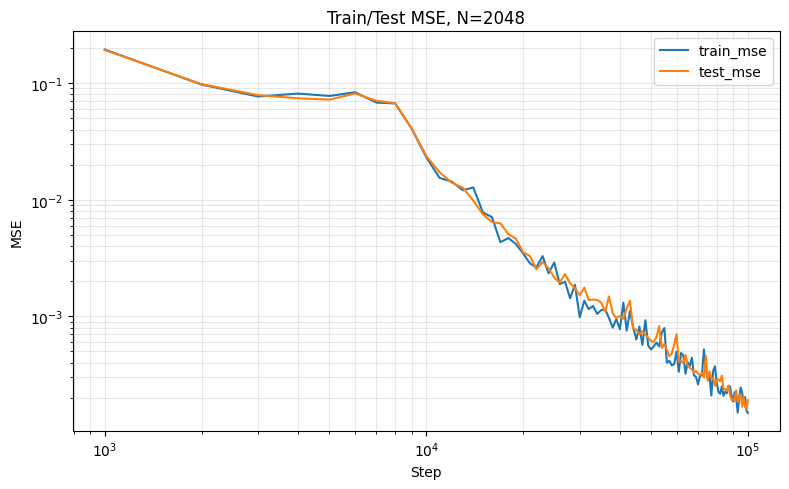

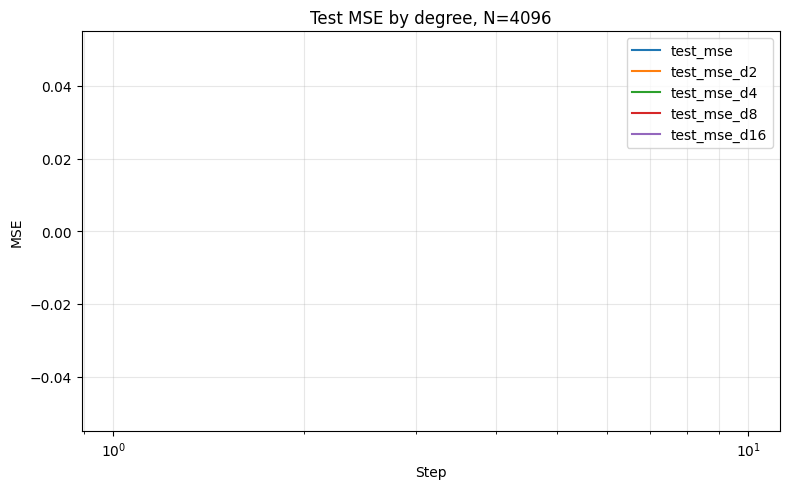

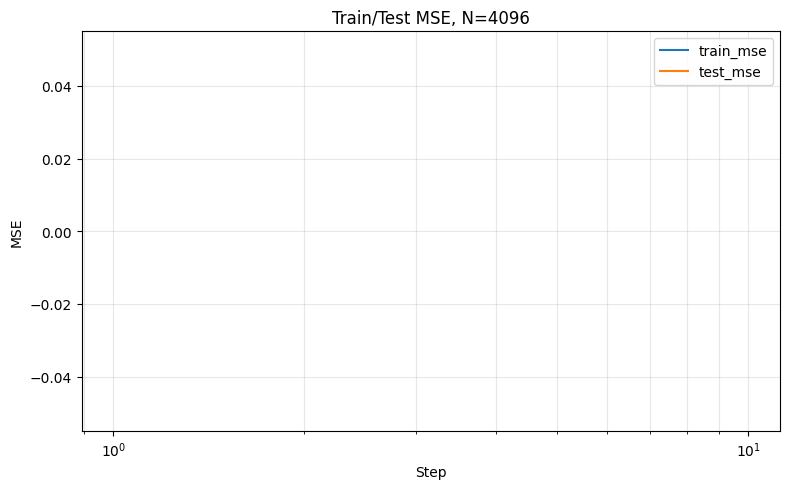

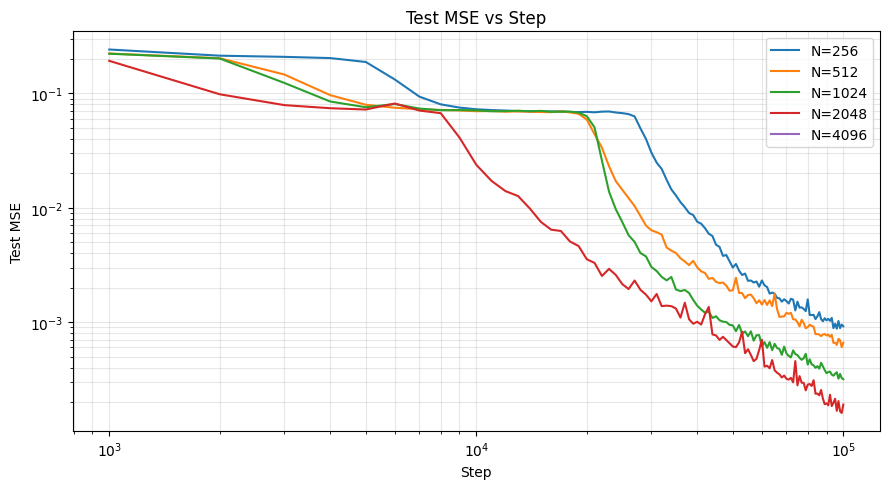

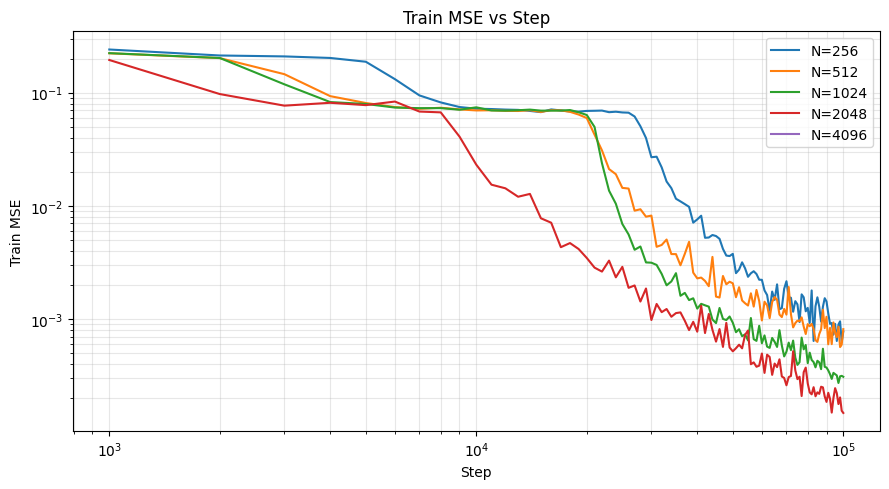

In [9]:
import matplotlib.pyplot as plt
import pandas as pd

USE_LOG_MSE_AXIS = True
USE_LOG_STEP_AXIS = True
TEST_MSE_COLUMNS = ["test_mse", "test_mse_d2", "test_mse_d4", "test_mse_d8", "test_mse_d16"]


def axis_has_positive_data(ax, axis):
    for line in ax.lines:
        values = line.get_xdata() if axis == "x" else line.get_ydata()
        if len(values) and pd.Series(values).dropna().gt(0).any():
            return True
    return False


def maybe_log_y(ax):
    if USE_LOG_MSE_AXIS and axis_has_positive_data(ax, "y"):
        ax.set_yscale("log")


def maybe_log_x(ax):
    if USE_LOG_STEP_AXIS and axis_has_positive_data(ax, "x"):
        ax.set_xscale("log")


metrics_by_width = {}
for N in WIDTHS:
    metrics_path = RUNS_DIR / f"N_{N}" / "metrics.csv"
    if not metrics_path.exists():
        print(f"N={N}: missing {metrics_path}")
        continue
    df = pd.read_csv(metrics_path)
    metrics_by_width[N] = df

    fig, ax = plt.subplots(figsize=(8, 5))
    for column in TEST_MSE_COLUMNS:
        if column in df.columns:
            ax.plot(df["step"], df[column], label=column)
    ax.set_xlabel("Step")
    ax.set_ylabel("MSE")
    ax.set_title(f"Test MSE by degree, N={N}")
    maybe_log_x(ax)
    maybe_log_y(ax)
    ax.grid(True, alpha=0.3, which="both")
    ax.legend()
    fig.tight_layout()
    fig.savefig(PLOTS_DIR / f"test_mse_by_degree_N_{N}.png", dpi=150)
    plt.show()

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(df["step"], df["train_mse"], label="train_mse")
    ax.plot(df["step"], df["test_mse"], label="test_mse")
    ax.set_xlabel("Step")
    ax.set_ylabel("MSE")
    ax.set_title(f"Train/Test MSE, N={N}")
    maybe_log_x(ax)
    maybe_log_y(ax)
    ax.grid(True, alpha=0.3, which="both")
    ax.legend()
    fig.tight_layout()
    fig.savefig(PLOTS_DIR / f"train_test_mse_N_{N}.png", dpi=150)
    plt.show()

fig, ax = plt.subplots(figsize=(9, 5))
for N, df in metrics_by_width.items():
    ax.plot(df["step"], df["test_mse"], label=f"N={N}")
ax.set_xlabel("Step")
ax.set_ylabel("Test MSE")
ax.set_title("Test MSE vs Step")
maybe_log_x(ax)
maybe_log_y(ax)
ax.grid(True, alpha=0.3, which="both")
ax.legend()
fig.tight_layout()
fig.savefig(PLOTS_DIR / "test_mse_by_width.png", dpi=150)
plt.show()

fig, ax = plt.subplots(figsize=(9, 5))
for N, df in metrics_by_width.items():
    ax.plot(df["step"], df["train_mse"], label=f"N={N}")
ax.set_xlabel("Step")
ax.set_ylabel("Train MSE")
ax.set_title("Train MSE vs Step")
maybe_log_x(ax)
maybe_log_y(ax)
ax.grid(True, alpha=0.3, which="both")
ax.legend()
fig.tight_layout()
fig.savefig(PLOTS_DIR / "train_mse_by_width.png", dpi=150)
plt.show()


## Final-Checkpoint PCA and Weight-Variance Analysis

For each final checkpoint, load the saved test set, compute PCA ranks at the selected residual-stream layer, sweep PCA interventions, and collect trained weight variances.


N=256: collecting activations from 20000 saved test samples


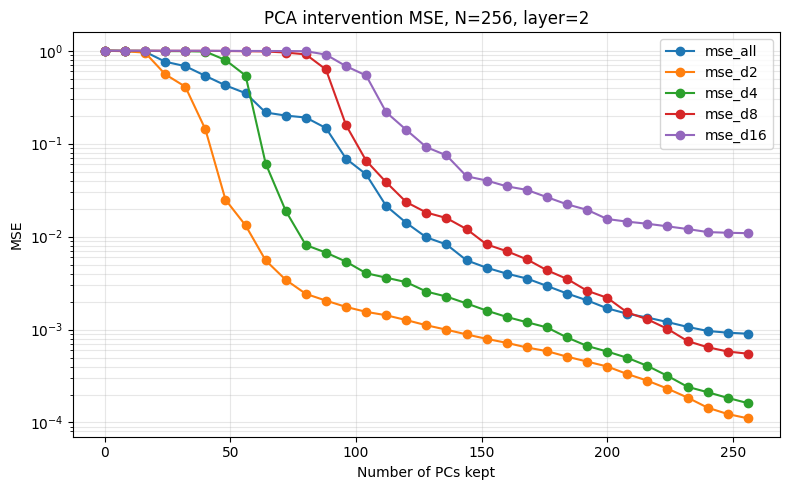

N=512: collecting activations from 20000 saved test samples


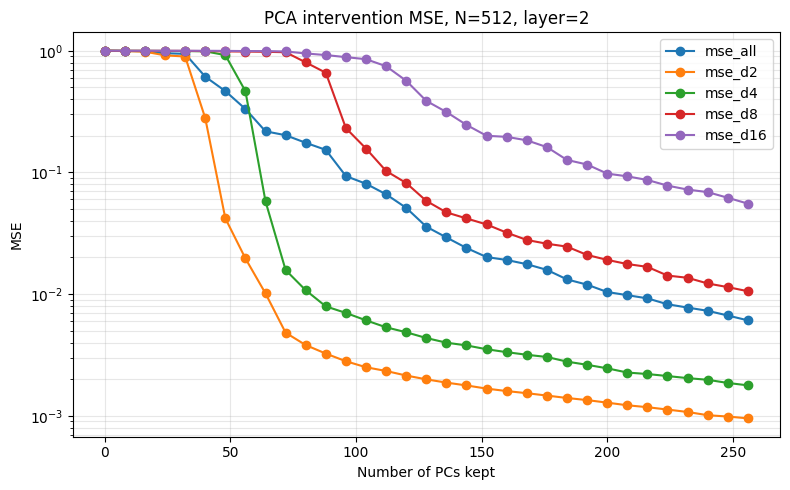

N=1024: collecting activations from 20000 saved test samples


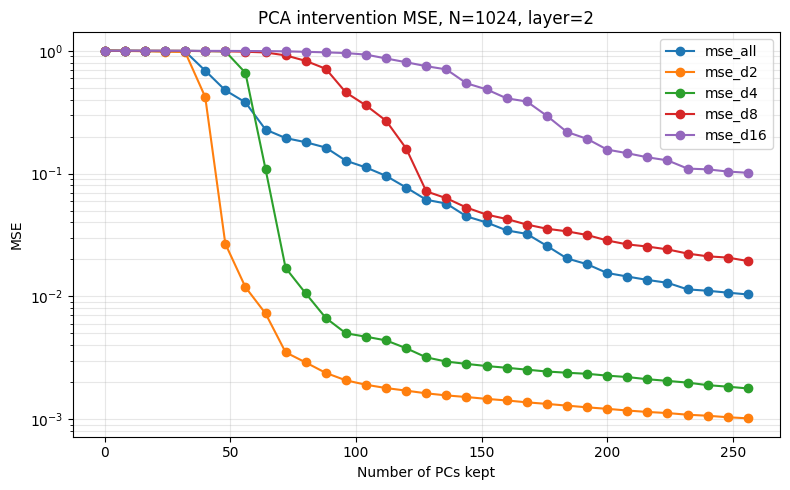

N=2048: collecting activations from 20000 saved test samples


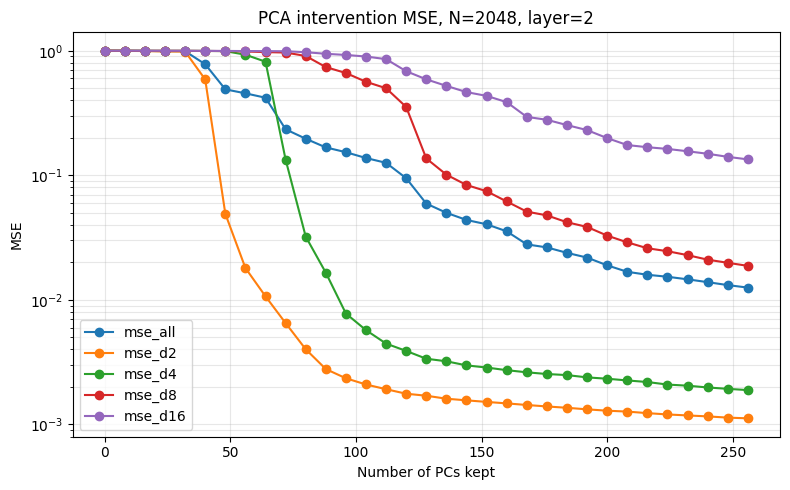

N=4096: missing final checkpoint, skipping analysis


,N,layer_idx,rank_90,rank_99,num_dimensions
0,256,0,28,32,256
1,256,1,31,57,256
2,256,2,37,81,256
3,512,0,29,32,512
4,512,1,31,66,512
5,512,2,37,134,512
6,1024,0,29,32,1024
7,1024,1,31,68,1024
8,1024,2,37,236,1024
9,2048,0,29,32,2048


,N,layer,variance
0,256,embedding.weight,0.032030
1,256,blocks.0.linear.weight,0.004159
2,256,blocks.1.linear.weight,0.003927
3,256,readout.weight,0.009659
4,512,embedding.weight,0.030711
5,512,blocks.0.linear.weight,0.001998
6,512,blocks.1.linear.weight,0.001934
7,512,readout.weight,0.003463
8,1024,embedding.weight,0.030519
9,1024,blocks.0.linear.weight,0.000982


In [10]:
import torch

from parity_net.analysis import (
    collect_layer_activations,
    make_pca_intervention,
    pca_from_activations,
    per_degree_mse,
    predict_in_batches,
    rank_for_threshold,
)
from parity_net.checkpoint import load_checkpoint
from parity_net.data import ParityDataset, load_dataset
from parity_net.train import resolve_device, resolve_dtype

PCA_SAMPLES = 20_000
USE_LOG_PCA_MSE_AXIS = True
ANALYSIS_LAYER_IDX = 2  # with L=1: 0 is embedding, 1 is after the only residual block
KEEP_PCS_MIN = 0
KEEP_PCS_MAX = 256
KEEP_PCS_STEP = 8

rank_rows = []
weight_rows = []
pca_sweep_by_width = {}

for N in WIDTHS:
    run_dir = RUNS_DIR / f"N_{N}"
    checkpoint_path = run_dir / "checkpoints" / "final.pt"
    if not checkpoint_path.exists():
        print(f"N={N}: missing final checkpoint, skipping analysis")
        continue

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model, payload, _ = load_checkpoint(checkpoint_path, device)
    training = payload["config"]["training"]
    model_config = payload["config"]["model"]
    device = resolve_device(training["device"])
    dtype = resolve_dtype(training["dtype"])
    model = model.to(device=device, dtype=dtype)
    batch_size = training["batch_size"]

    test_data_path = Path(payload.get("test_data_path") or run_dir / "test_data.pt")
    test_data = load_dataset(test_data_path, device, dtype)
    if PCA_SAMPLES < test_data.x.shape[0]:
        heldout = ParityDataset(x=test_data.x[:PCA_SAMPLES], y=test_data.y[:PCA_SAMPLES])
    else:
        heldout = test_data

    for layer, variance in model.weight_variances().items():
        weight_rows.append({"N": N, "layer": layer, "variance": variance})

    print(f"N={N}: collecting activations from {heldout.x.shape[0]} saved test samples")
    activations = collect_layer_activations(model, heldout.x, batch_size)
    pcas = [pca_from_activations(layer_acts) for layer_acts in activations]

    for layer_idx, pca in enumerate(pcas):
        cumulative = pca["cumulative_explained_variance"]
        rank_rows.append(
            {
                "N": N,
                "layer_idx": layer_idx,
                "rank_90": rank_for_threshold(cumulative, 0.90),
                "rank_99": rank_for_threshold(cumulative, 0.99),
                "num_dimensions": cumulative.numel(),
            }
        )

    if ANALYSIS_LAYER_IDX < 0 or ANALYSIS_LAYER_IDX >= len(pcas):
        raise ValueError(f"ANALYSIS_LAYER_IDX must be in [0, {len(pcas) - 1}]")

    max_available_pcs = pcas[ANALYSIS_LAYER_IDX]["components"].shape[0]
    keep_pcs_max_effective = min(KEEP_PCS_MAX, max_available_pcs)
    keep_pcs_values = list(range(KEEP_PCS_MIN, keep_pcs_max_effective + 1, KEEP_PCS_STEP))
    if keep_pcs_values[-1] != keep_pcs_max_effective:
        keep_pcs_values.append(keep_pcs_max_effective)

    sweep_rows = []
    for keep_pcs in keep_pcs_values:
        intervention = make_pca_intervention(pcas[ANALYSIS_LAYER_IDX], keep_pcs)
        with torch.no_grad():
            pred_intervened = predict_in_batches(
                model,
                heldout.x,
                batch_size,
                intervention=(ANALYSIS_LAYER_IDX, intervention),
            )
        sweep_rows.append(
            {
                "N": N,
                "intervention_layer": ANALYSIS_LAYER_IDX,
                "keep_pcs": keep_pcs,
                **per_degree_mse(pred_intervened, heldout.y),
            }
        )

    sweep_df = pd.DataFrame(sweep_rows)
    pca_sweep_by_width[N] = sweep_df
    sweep_df.to_csv(ANALYSIS_DIR / f"pca_mse_sweep_N_{N}.csv", index=False)

    fig, ax = plt.subplots(figsize=(8, 5))
    sweep_df.plot(
        x="keep_pcs",
        y=["mse_all", "mse_d2", "mse_d4", "mse_d8", "mse_d16"],
        marker="o",
        ax=ax,
    )
    ax.set_xlabel("Number of PCs kept")
    ax.set_ylabel("MSE")
    ax.set_title(f"PCA intervention MSE, N={N}, layer={ANALYSIS_LAYER_IDX}")
    if USE_LOG_PCA_MSE_AXIS:
        ax.set_yscale("log")
    ax.grid(True, alpha=0.3, which="both")
    fig.tight_layout()
    fig.savefig(PLOTS_DIR / f"pca_mse_sweep_N_{N}.png", dpi=150)
    plt.show()

rank_df = pd.DataFrame(rank_rows)
weight_variance_df = pd.DataFrame(weight_rows)
rank_df.to_csv(ANALYSIS_DIR / "pca_ranks_by_width.csv", index=False)
weight_variance_df.to_csv(ANALYSIS_DIR / "weight_variances_by_width.csv", index=False)

display(rank_df)
display(weight_variance_df)


## Summary Plots

Plot effective residual-stream dimension versus width, PCA intervention curves across widths, and trained weight variance scaling versus width.


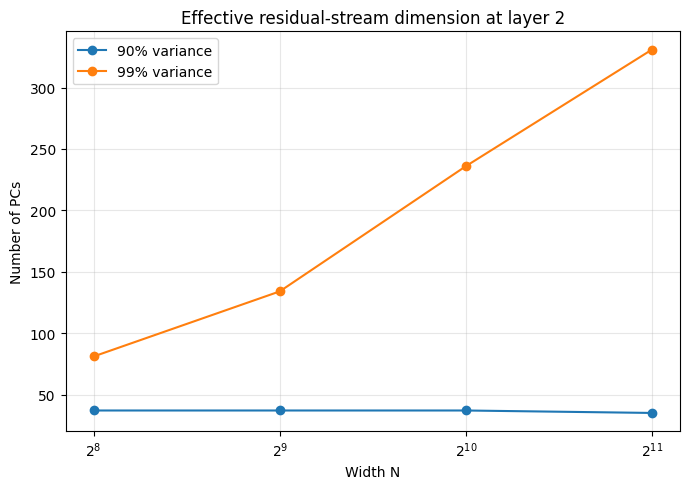

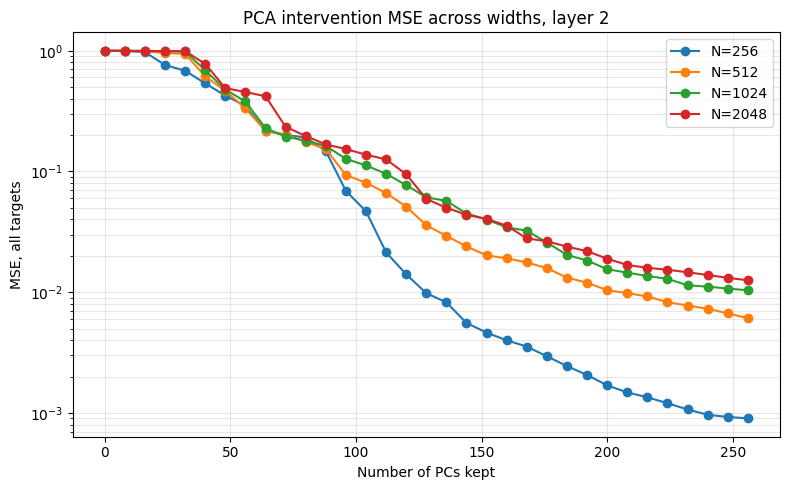

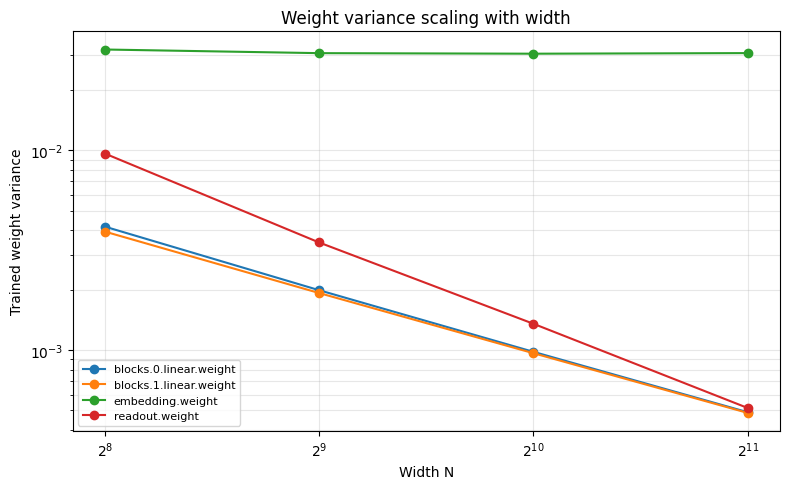

In [11]:
layer_rank_df = rank_df[rank_df["layer_idx"] == ANALYSIS_LAYER_IDX].copy()

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(layer_rank_df["N"], layer_rank_df["rank_90"], marker="o", label="90% variance")
ax.plot(layer_rank_df["N"], layer_rank_df["rank_99"], marker="o", label="99% variance")
ax.set_xscale("log", base=2)
ax.set_xlabel("Width N")
ax.set_ylabel("Number of PCs")
ax.set_title(f"Effective residual-stream dimension at layer {ANALYSIS_LAYER_IDX}")
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
fig.savefig(PLOTS_DIR / "effective_dimension_vs_width.png", dpi=150)
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
for N, sweep_df in pca_sweep_by_width.items():
    ax.plot(sweep_df["keep_pcs"], sweep_df["mse_all"], marker="o", label=f"N={N}")
ax.set_xlabel("Number of PCs kept")
ax.set_ylabel("MSE, all targets")
ax.set_title(f"PCA intervention MSE across widths, layer {ANALYSIS_LAYER_IDX}")
if USE_LOG_PCA_MSE_AXIS:
    ax.set_yscale("log")
ax.grid(True, alpha=0.3, which="both")
ax.legend()
fig.tight_layout()
fig.savefig(PLOTS_DIR / "pca_mse_all_sweep_by_width.png", dpi=150)
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
for layer, group in weight_variance_df.groupby("layer"):
    group = group.sort_values("N")
    ax.plot(group["N"], group["variance"], marker="o", label=layer)
ax.set_xscale("log", base=2)
ax.set_yscale("log")
ax.set_xlabel("Width N")
ax.set_ylabel("Trained weight variance")
ax.set_title("Weight variance scaling with width")
ax.grid(True, alpha=0.3, which="both")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(PLOTS_DIR / "weight_variance_vs_width.png", dpi=150)
plt.show()
